In [1]:
!git clone https://github.com/Lornatang/SRGAN-PyTorch.git
!cd SRGAN-PyTorch

Cloning into 'SRGAN-PyTorch'...
remote: Enumerating objects: 3631, done.
remote: Counting objects: 100% (918/918), done.
remote: Compressing objects: 100% (277/277), done.
remote: Total 3631 (delta 688), reused 814 (delta 637), pack-reused 2713 (from 1)
Receiving objects: 100% (3631/3631), 2.98 MiB | 8.24 MiB/s, done.
Resolving deltas: 100% (2385/2385), done.


In [12]:
import sys
print("⏳ Installing PyTorch (CPU-only) for inference...")
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu --break-system-packages
print("✅ Installation complete!")

⏳ Installing PyTorch (CPU-only) for inference...
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.9/188.9 MB 6.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.8 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 kB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 7.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.4 MB/s eta 0:00:00
Using cached filelock-3.20.0-py3-none-any.whl (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 6.6 MB/s eta 0:00:0000:0100:01
✅ Installation complete!


🚀 Running SRGAN Inference on CPU...
Build `srresnet_x4` model successfully.
Load `srresnet_x4` model weights `/home/clauds/PycharmProjects/SRGAN-Model/SRGAN-PyTorch/epoch_90_ImageNet.pth.tar` successfully.
SR image save to `sr_result.png`
✅ Inference complete! Rendering comparison...


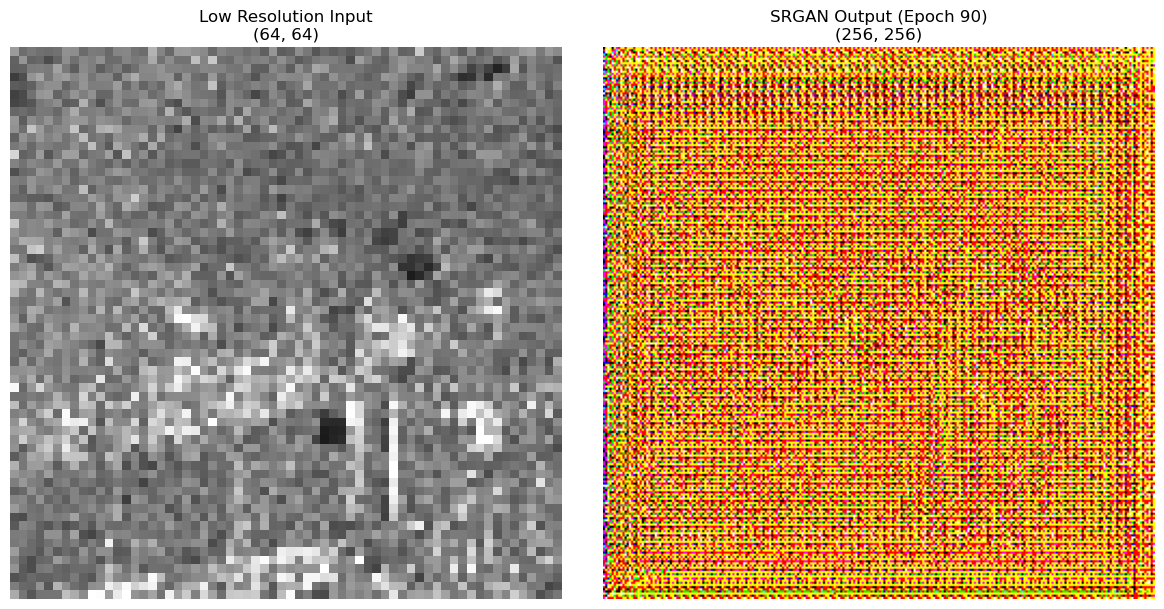

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys

# 1. Tell the notebook to step inside the cloned repo folder
if os.path.basename(os.getcwd()) != 'SRGAN-PyTorch':
    try:
        os.chdir('SRGAN-PyTorch')
        print(f"📁 Moved into: {os.getcwd()}")
    except FileNotFoundError:
        print("❌ Error: Could not find the SRGAN-PyTorch folder.")

# 2. UPDATED FILE PATHS TO MATCH YOUR SCREENSHOT EXACTLY
lr_img_path = "test_lr/patch_000025.png"         # Pointing inside the test_lr folder
sr_img_path = "sr_result.png"                    # Where it will save the output
weights_path = "epoch_90_ImageNet.pth.tar"       # Updated to match your custom file name

# Quick check to ensure the files are found
if not os.path.exists(weights_path):
    print(f"❌ Error: I can't find '{weights_path}'.")
elif not os.path.exists(lr_img_path):
    print(f"❌ Error: I can't find '{lr_img_path}'.")
else:
    # 3. Run the inference script
    print("🚀 Running SRGAN Inference on CPU...")
    !{sys.executable} inference.py --model_weights_path {weights_path} --inputs {lr_img_path} --output {sr_img_path} --device cpu

    # 4. Visualize the results
    if os.path.exists(sr_img_path):
        print("✅ Inference complete! Rendering comparison...")
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Load the images
        img_lr = Image.open(lr_img_path)
        img_sr = Image.open(sr_img_path)

        # Plot Low Res
        axes[0].imshow(img_lr, cmap='gray' if img_lr.mode == 'L' else None)
        axes[0].set_title(f"Low Resolution Input\n{img_lr.size}")
        axes[0].axis('off')

        # Plot Super Res
        axes[1].imshow(img_sr, cmap='gray' if img_sr.mode == 'L' else None)
        axes[1].set_title(f"SRGAN Output (Epoch 90)\n{img_sr.size}")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(f"❌ Error: Inference failed. Could not find {sr_img_path}.")

### digging to see what phase 1 actually produced

🚀 Running Phase 1 (ResNet) Inference...
Build `srresnet_x4` model successfully.
Load `srresnet_x4` model weights `/home/clauds/PycharmProjects/SRGAN-Model/SRGAN-PyTorch/epoch_90_ResNet.pth.tar` successfully.
SR image save to `sr_result_phase1.png`
✅ Inference complete! Rendering Phase 1 comparison...


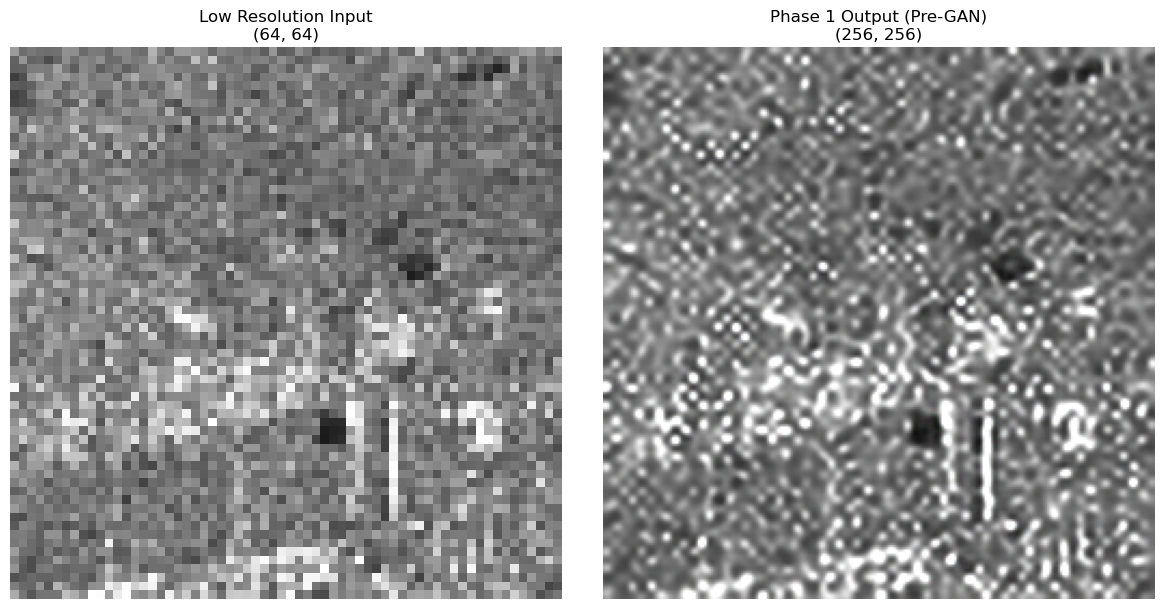

In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys

# 1. Stay in the right folder
if os.path.basename(os.getcwd()) != 'SRGAN-PyTorch':
    try:
        os.chdir('SRGAN-PyTorch')
    except FileNotFoundError:
        pass

# 2. File Paths (Looking for Phase 1 / ResNet this time)
lr_img_path = "test_lr/patch_000025.png"
sr_img_path = "sr_result_phase1.png"
weights_path = "epoch_90_ResNet.pth.tar"

if not os.path.exists(weights_path):
    print(f"❌ Error: I can't find '{weights_path}'.")
else:
    # 3. Run the inference script (ARGUMENTS CORRECTED)
    print("🚀 Running Phase 1 (ResNet) Inference...")
    !{sys.executable} inference.py --model_weights_path {weights_path} --inputs {lr_img_path} --output {sr_img_path} --device cpu

    # 4. Visualize the results
    if os.path.exists(sr_img_path):
        print("✅ Inference complete! Rendering Phase 1 comparison...")
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        img_lr = Image.open(lr_img_path)
        img_sr = Image.open(sr_img_path)

        axes[0].imshow(img_lr, cmap='gray' if img_lr.mode == 'L' else None)
        axes[0].set_title(f"Low Resolution Input\n{img_lr.size}")
        axes[0].axis('off')

        axes[1].imshow(img_sr, cmap='gray' if img_sr.mode == 'L' else None)
        axes[1].set_title(f"Phase 1 Output (Pre-GAN)\n{img_sr.size}")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()